# MNIST OT application

This notebook was used to run the MNIST experiments and generate the results on the paper.

## Imports and project setup

In [1]:
import os
import sys
import time
from pathlib import Path

import ot
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST

PROJECT_ROOT = Path.cwd().resolve().parents[0]
SRC_DIR = PROJECT_ROOT / "src"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CACHE_DIR = OUTPUT_DIR / "cached"

CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from core import make_grid_2d, squared_euclidean_cost, sinkhorn_log
from utils import mnist_image_to_histogram, batch_images_to_histograms, select_examples_by_label, pairwise_sinkhorn_cost_matrix, euclidean_average_histogram, wasserstein_barycenter_same_support, weighted_group_euclidean_average, weighted_group_wasserstein_barycenter, mnist_image_to_unit_interval_vector, batch_images_to_unit_interval_vectors, select_balanced_subset, euclidean_query_candidate_distances, sinkhorn_cost_pot, sinkhorn_query_candidate_distances, retrieval_topk_indices, topk_same_label_stats, show_retrieval_panel

np.random.seed(0)

## Load MNIST

In [2]:
DATA_ROOT = PROJECT_ROOT / "data"

train_ds = MNIST(root=DATA_ROOT, train=True, download=True)
test_ds = MNIST(root=DATA_ROOT, train=False, download=True)

In [3]:
print(f"Loaded {len(train_ds):,} training images and {len(test_ds):,} test images.")

Loaded 60,000 training images and 10,000 test images.


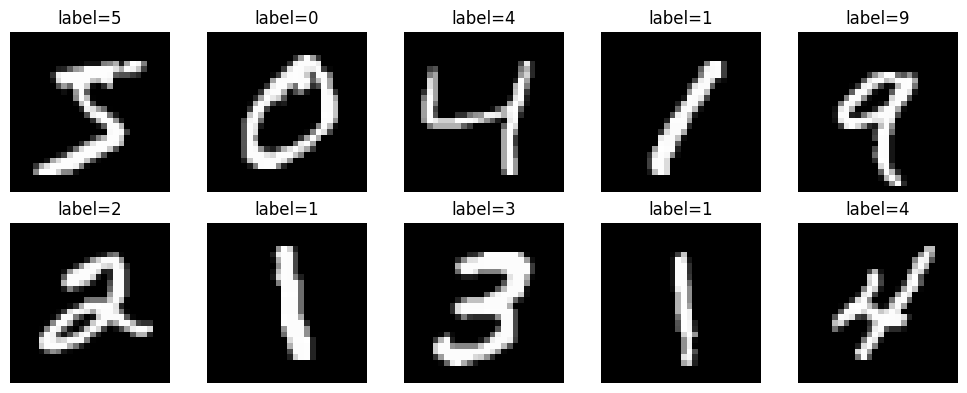

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, idx in zip(axes.ravel(), range(10)):
    img, y = train_ds[idx]
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"label={y}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Convert MNIST images into histograms

Planned preprocessing:


$$
I \mapsto I/255 \mapsto (I + \eta) / \sum (I + \eta).
$$

Each image becomes a histogram in the simplex of dimension 784.

In [5]:
img, y = train_ds[0]
h = mnist_image_to_histogram(img, eta=1e-8)

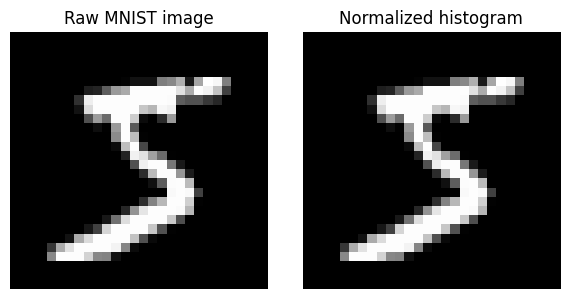

In [6]:
img_arr = np.asarray(train_ds[0][0], dtype=np.float64)
hist_img = mnist_image_to_histogram(train_ds[0][0], eta=1e-8).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_arr, cmap="gray")
axes[0].set_title("Raw MNIST image")
axes[0].axis("off")

axes[1].imshow(hist_img, cmap="gray")
axes[1].set_title("Normalized histogram")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
grid = make_grid_2d(28, 28, normalize=True)

## Common support, ground cost, and example measures

Use a fixed normalized 28x28 grid and squared Euclidean cost.

In [8]:
cost_path = CACHE_DIR / "mnist_cost_sqeuclidean.npy"

if cost_path.exists():
    C_mnist = np.load(cost_path)
    print("Loaded cached cost matrix from:", cost_path)
else:
    C_mnist = squared_euclidean_cost(grid)
    np.save(cost_path, C_mnist)
    print("Built and cached cost matrix at:", cost_path)

Loaded cached cost matrix from: /home/choukrani/ot/outputs/cached/mnist_cost_sqeuclidean.npy


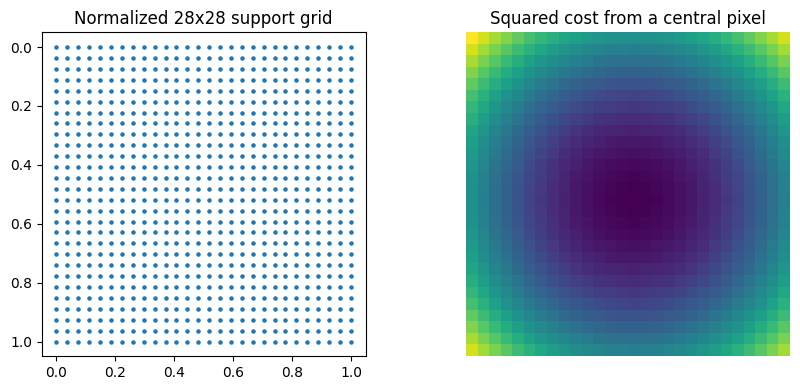

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].scatter(grid[:, 0], grid[:, 1], s=5)
axes[0].set_title("Normalized 28x28 support grid")
axes[0].set_aspect("equal")
axes[0].invert_yaxis()

center_idx = 14 * 28 + 14
axes[1].imshow(C_mnist[center_idx].reshape(28, 28), cmap="viridis")
axes[1].set_title("Squared cost from a central pixel")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
images_0, idx_0 = select_examples_by_label(train_ds, label=0, k=8, seed=0)
H_0 = batch_images_to_histograms(images_0, eta=1e-8)

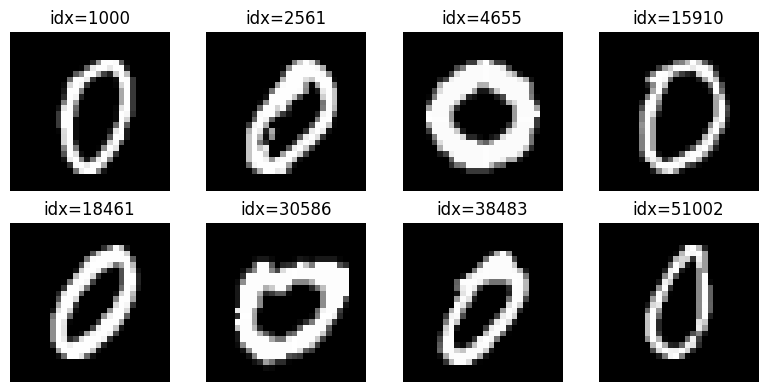

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for ax, img, idx in zip(axes.ravel(), images_0, idx_0):
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"idx={idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Pairwise Sinkhorn distances

In [12]:
ETA = 1e-8
EPS_VALUES = [0.002, 0.005, 0.01, 0.02, 0.05]
SINKHORN_TOL = 1e-6
SINKHORN_MAX_ITER = 5000

In [13]:
images_0, idx_0 = select_examples_by_label(train_ds, label=0, k=3, seed=0)
images_1, idx_1 = select_examples_by_label(train_ds, label=1, k=3, seed=1)

tiny_images = images_0 + images_1
tiny_labels = np.array([0] * len(images_0) + [1] * len(images_1), dtype=int)
tiny_indices = np.concatenate([idx_0, idx_1])

H_tiny = batch_images_to_histograms(tiny_images, eta=1e-8)

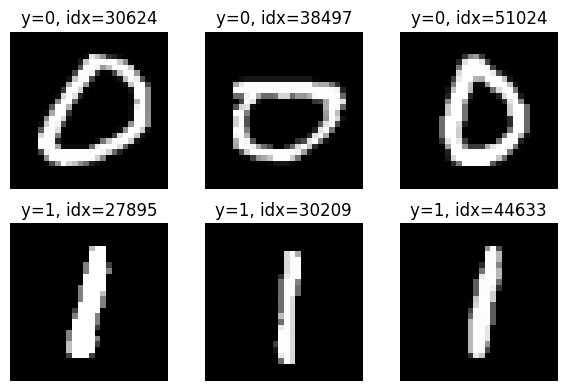

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4))

for ax, img, y, idx in zip(axes.ravel(), tiny_images, tiny_labels, tiny_indices):
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"y={y}, idx={idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
PAIRWISE_EPS = 0.02
PAIRWISE_MAX_ITER = 1500
PAIRWISE_TOL = 1e-5

D_tiny, iters_tiny, conv_tiny, runtime_tiny = pairwise_sinkhorn_cost_matrix(
    H_tiny,
    C_mnist,
    eps=PAIRWISE_EPS,
    max_iter=PAIRWISE_MAX_ITER,
    tol=PAIRWISE_TOL,
    verbose=True,
)

[0,0] cost=0.01228127 | iters=60 | converged=True
[0,1] cost=0.02013677 | iters=70 | converged=True
[0,2] cost=0.01935667 | iters=60 | converged=True
[0,3] cost=0.04271571 | iters=40 | converged=True
[0,4] cost=0.04864414 | iters=50 | converged=True
[0,5] cost=0.04505186 | iters=60 | converged=True
[1,1] cost=0.01232375 | iters=50 | converged=True
[1,2] cost=0.02169835 | iters=60 | converged=True
[1,3] cost=0.04890944 | iters=50 | converged=True
[1,4] cost=0.05577101 | iters=50 | converged=True
[1,5] cost=0.05225895 | iters=40 | converged=True
[2,2] cost=0.01300562 | iters=40 | converged=True
[2,3] cost=0.02858123 | iters=50 | converged=True
[2,4] cost=0.03095830 | iters=40 | converged=True
[2,5] cost=0.03059438 | iters=50 | converged=True
[3,3] cost=0.01192807 | iters=40 | converged=True
[3,4] cost=0.01317542 | iters=40 | converged=True
[3,5] cost=0.01309198 | iters=50 | converged=True
[4,4] cost=0.01024611 | iters=30 | converged=True
[4,5] cost=0.01208962 | iters=50 | converged=True


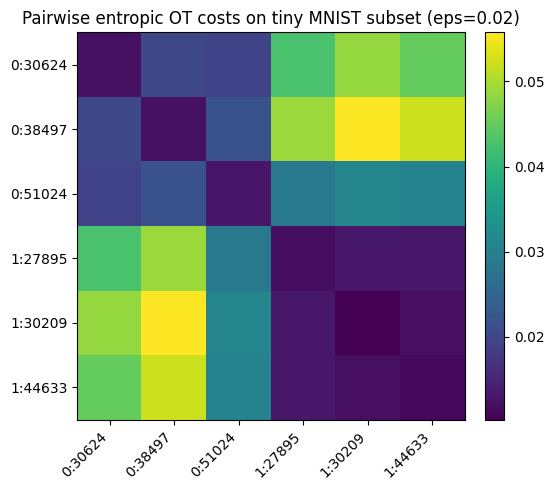

In [16]:
tick_labels = [f"{y}:{idx}" for y, idx in zip(tiny_labels, tiny_indices)]

plt.figure(figsize=(6, 5))
im = plt.imshow(D_tiny, cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha="right")
plt.yticks(range(len(tick_labels)), tick_labels)
plt.title(f"Pairwise entropic OT costs on tiny MNIST subset (eps={PAIRWISE_EPS})")
plt.tight_layout()
plt.show()

In [17]:
same_class_costs = []
diff_class_costs = []

N = len(tiny_labels)
for i in range(N):
    for j in range(i + 1, N):
        if tiny_labels[i] == tiny_labels[j]:
            same_class_costs.append(D_tiny[i, j])
        else:
            diff_class_costs.append(D_tiny[i, j])

same_class_costs = np.array(same_class_costs, dtype=np.float64)
diff_class_costs = np.array(diff_class_costs, dtype=np.float64)

print(f"Mean same-class cost:      {same_class_costs.mean():.4f}")
print(f"Mean different-class cost: {diff_class_costs.mean():.4f}")

Mean same-class cost:      0.0166
Mean different-class cost: 0.0426


In [18]:
print("Nearest-neighbor sanity check (excluding self):\n")

N = len(tiny_labels)
for i in range(N):
    candidates = D_tiny[i].copy()
    candidates[i] = np.inf
    j_star = int(np.argmin(candidates))

    print(
        f"query {i} (label={tiny_labels[i]}, idx={tiny_indices[i]}) --> "
        f"nn {j_star} (label={tiny_labels[j_star]}, idx={tiny_indices[j_star]}) | "
        f"cost={D_tiny[i, j_star]:.8f} | "
        f"same_label={tiny_labels[i] == tiny_labels[j_star]}"
    )

Nearest-neighbor sanity check (excluding self):

query 0 (label=0, idx=30624) --> nn 2 (label=0, idx=51024) | cost=0.01935667 | same_label=True
query 1 (label=0, idx=38497) --> nn 0 (label=0, idx=30624) | cost=0.02013677 | same_label=True
query 2 (label=0, idx=51024) --> nn 0 (label=0, idx=30624) | cost=0.01935667 | same_label=True
query 3 (label=1, idx=27895) --> nn 5 (label=1, idx=44633) | cost=0.01309198 | same_label=True
query 4 (label=1, idx=30209) --> nn 5 (label=1, idx=44633) | cost=0.01208962 | same_label=True
query 5 (label=1, idx=44633) --> nn 4 (label=1, idx=30209) | cost=0.01208962 | same_label=True


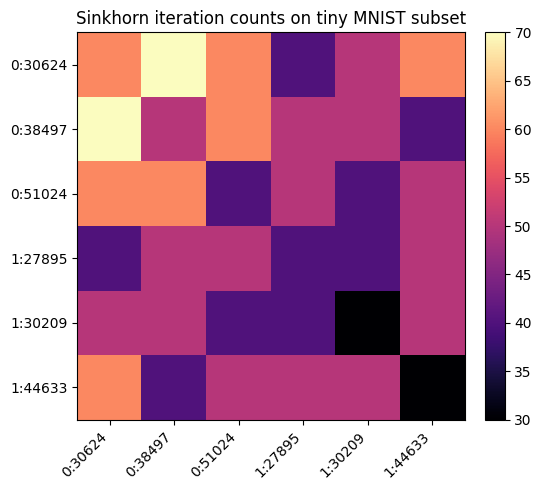

In [19]:
plt.figure(figsize=(6, 5))
im = plt.imshow(iters_tiny, cmap="magma")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha="right")
plt.yticks(range(len(tick_labels)), tick_labels)
plt.title("Sinkhorn iteration counts on tiny MNIST subset")
plt.tight_layout()
plt.show()

## Same-class Wasserstein barycenters 

In [20]:
BARY_LABEL = 0
BARY_K = 8
BARY_SEED = 0

images_same, idx_same = select_examples_by_label(
    train_ds, label=BARY_LABEL, k=BARY_K, seed=BARY_SEED
)
H_same = batch_images_to_histograms(images_same, eta=ETA)

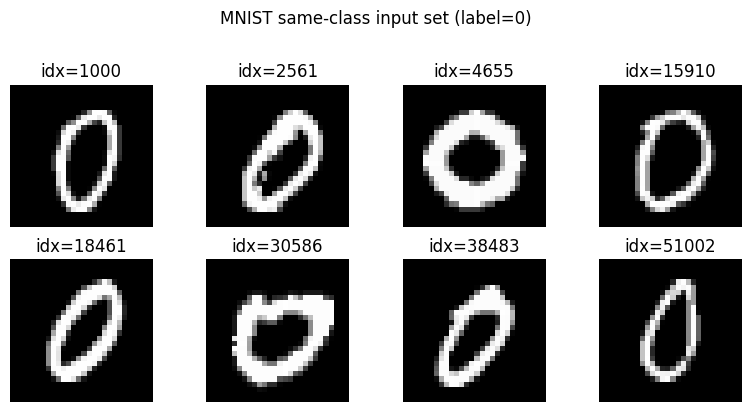

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for ax, img, idx in zip(axes.ravel(), images_same, idx_same):
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"idx={idx}")
    ax.axis("off")

plt.suptitle(f"MNIST same-class input set (label={BARY_LABEL})", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
BARY_EPS_VALUES = [0.005, 0.01, 0.02, 0.05]
BARY_NUM_ITER = 5000
BARY_STOP_THR = 1e-6

weights_same = np.ones(BARY_K, dtype=np.float64) / BARY_K

eucl_avg = euclidean_average_histogram(H_same)

bary_results = {}
for eps in BARY_EPS_VALUES:
    bary, runtime_sec = wasserstein_barycenter_same_support(
        H_same,
        C_mnist,
        eps=eps,
        weights=weights_same,
        numItermax=BARY_NUM_ITER,
        stopThr=BARY_STOP_THR,
    )
    bary_results[eps] = {
        "barycenter": bary,
        "runtime_sec": runtime_sec,
    }
    print(
        f"eps={eps:>6} | runtime={runtime_sec:.3f}s | "
        f"sum={bary.sum():.12f} | min={bary.min():.3e} | max={bary.max():.3e}"
    )

eps= 0.005 | runtime=32.022s | sum=1.000000000000 | min=4.148e-11 | max=5.637e-03
eps=  0.01 | runtime=17.004s | sum=1.000000000000 | min=4.584e-11 | max=4.642e-03
eps=  0.02 | runtime=8.123s | sum=1.000000000000 | min=7.590e-09 | max=3.669e-03
eps=  0.05 | runtime=3.690s | sum=1.000000000000 | min=6.843e-06 | max=2.826e-03


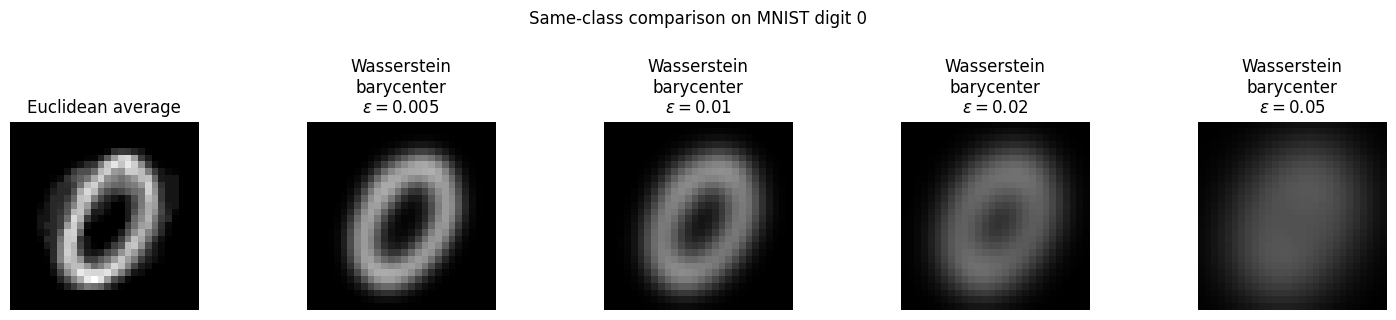

In [23]:
all_to_display = [eucl_avg] + [bary_results[eps]["barycenter"] for eps in BARY_EPS_VALUES]
vmax = max(arr.reshape(28, 28).max() for arr in all_to_display)

fig, axes = plt.subplots(1, 1 + len(BARY_EPS_VALUES), figsize=(3 * (1 + len(BARY_EPS_VALUES)), 3))

axes[0].imshow(eucl_avg.reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
axes[0].set_title("Euclidean average")
axes[0].axis("off")

for ax, eps in zip(axes[1:], BARY_EPS_VALUES):
    ax.imshow(bary_results[eps]["barycenter"].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(f"Wasserstein\nbarycenter\n$\\varepsilon={eps}$")
    ax.axis("off")

plt.suptitle(f"Same-class comparison on MNIST digit {BARY_LABEL}", y=1.05)
plt.tight_layout()
plt.show()

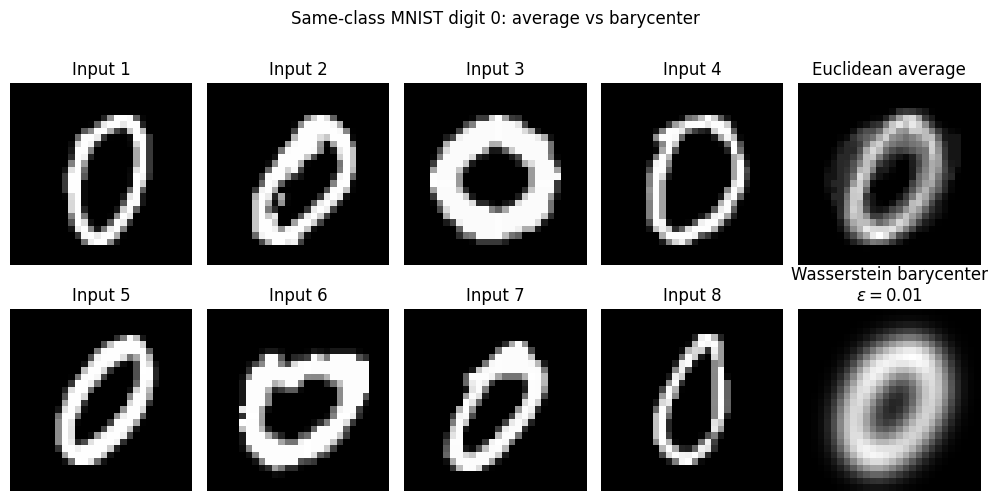

In [24]:
PREFERRED_EPS = 0.01

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 5)

# Top row: 4 example inputs
for k in range(4):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(np.asarray(images_same[k]), cmap="gray")
    ax.set_title(f"Input {k+1}")
    ax.axis("off")

# Bottom row: 4 more example inputs
for k in range(4, 8):
    ax = fig.add_subplot(gs[1, k - 4])
    ax.imshow(np.asarray(images_same[k]), cmap="gray")
    ax.set_title(f"Input {k+1}")
    ax.axis("off")

# Right column: Euclidean average and preferred barycenter
ax_avg = fig.add_subplot(gs[0, 4])
ax_avg.imshow(eucl_avg.reshape(28, 28), cmap="gray")
ax_avg.set_title("Euclidean average")
ax_avg.axis("off")

ax_bary = fig.add_subplot(gs[1, 4])
ax_bary.imshow(bary_results[PREFERRED_EPS]["barycenter"].reshape(28, 28), cmap="gray")
ax_bary.set_title(f"Wasserstein barycenter\n$\\varepsilon={PREFERRED_EPS}$")
ax_bary.axis("off")

plt.suptitle(f"Same-class MNIST digit {BARY_LABEL}: average vs barycenter", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
fig_path_1 = FIG_DIR / f"same_class_label_{BARY_LABEL}_avg_vs_bary_eps_grid.png"
fig_path_2 = FIG_DIR / f"same_class_label_{BARY_LABEL}_inputs_avg_vs_bary.png"

# Recreating Figure 1 for saving 
all_to_display = [eucl_avg] + [bary_results[eps]["barycenter"] for eps in BARY_EPS_VALUES]
vmax = max(arr.reshape(28, 28).max() for arr in all_to_display)

fig1, axes = plt.subplots(1, 1 + len(BARY_EPS_VALUES), figsize=(3 * (1 + len(BARY_EPS_VALUES)), 3))
axes[0].imshow(eucl_avg.reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
axes[0].set_title("Euclidean average")
axes[0].axis("off")

for ax, eps in zip(axes[1:], BARY_EPS_VALUES):
    ax.imshow(bary_results[eps]["barycenter"].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(f"Wasserstein\nbarycenter\n$\\varepsilon={eps}$")
    ax.axis("off")

plt.suptitle(f"Same-class comparison on MNIST digit {BARY_LABEL}", y=1.05)
plt.tight_layout()
plt.savefig(fig_path_1, dpi=200, bbox_inches="tight")
plt.close(fig1)

# Recreating Figure 2 for saving
fig2 = plt.figure(figsize=(10, 5))
gs = fig2.add_gridspec(2, 5)

for k in range(4):
    ax = fig2.add_subplot(gs[0, k])
    ax.imshow(np.asarray(images_same[k]), cmap="gray")
    ax.set_title(f"Input {k+1}")
    ax.axis("off")

for k in range(4, 8):
    ax = fig2.add_subplot(gs[1, k - 4])
    ax.imshow(np.asarray(images_same[k]), cmap="gray")
    ax.set_title(f"Input {k+1}")
    ax.axis("off")

ax_avg = fig2.add_subplot(gs[0, 4])
ax_avg.imshow(eucl_avg.reshape(28, 28), cmap="gray")
ax_avg.set_title("Euclidean average")
ax_avg.axis("off")

ax_bary = fig2.add_subplot(gs[1, 4])
ax_bary.imshow(bary_results[PREFERRED_EPS]["barycenter"].reshape(28, 28), cmap="gray")
ax_bary.set_title(f"Wasserstein barycenter\n$\\varepsilon={PREFERRED_EPS}$")
ax_bary.axis("off")

plt.suptitle(f"Same-class MNIST digit {BARY_LABEL}: average vs barycenter", y=1.02)
plt.tight_layout()
plt.savefig(fig_path_2, dpi=200, bbox_inches="tight")
plt.close(fig2)

print("Saved:", fig_path_1)
print("Saved:", fig_path_2)

Saved: /home/choukrani/ot/outputs/figures/same_class_label_0_avg_vs_bary_eps_grid.png
Saved: /home/choukrani/ot/outputs/figures/same_class_label_0_inputs_avg_vs_bary.png


In [26]:
print(f"Same-class barycenter summary (label={BARY_LABEL})")
print("-" * 60)
print(f"{'eps':>8} | {'runtime (s)':>12} | {'max value':>12} | {'min value':>12}")
print("-" * 60)
for eps in BARY_EPS_VALUES:
    bary = bary_results[eps]["barycenter"]
    runtime_sec = bary_results[eps]["runtime_sec"]
    print(f"{eps:8.3g} | {runtime_sec:12.4f} | {bary.max():12.4e} | {bary.min():12.4e}")

Same-class barycenter summary (label=0)
------------------------------------------------------------
     eps |  runtime (s) |    max value |    min value
------------------------------------------------------------
   0.005 |      32.0223 |   5.6373e-03 |   4.1485e-11
    0.01 |      17.0036 |   4.6422e-03 |   4.5837e-11
    0.02 |       8.1226 |   3.6688e-03 |   7.5901e-09
    0.05 |       3.6901 |   2.8264e-03 |   6.8429e-06


## Mixed-class Wasserstein interpolation 

In [27]:
LABEL_A = 0
LABEL_B = 8
K_A = 4
K_B = 4
SEED_A = 0
SEED_B = 1

images_A, idx_A = select_examples_by_label(train_ds, label=LABEL_A, k=K_A, seed=SEED_A)
images_B, idx_B = select_examples_by_label(train_ds, label=LABEL_B, k=K_B, seed=SEED_B)

H_A = batch_images_to_histograms(images_A, eta=ETA)
H_B = batch_images_to_histograms(images_B, eta=ETA)

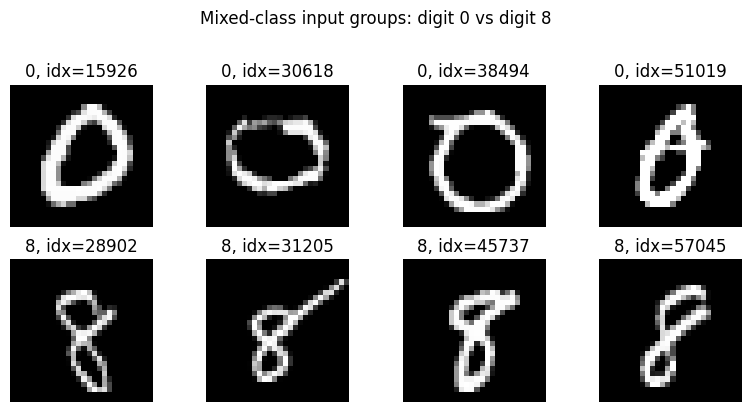

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for ax, img, idx in zip(axes[0], images_A, idx_A):
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"{LABEL_A}, idx={idx}")
    ax.axis("off")

for ax, img, idx in zip(axes[1], images_B, idx_B):
    ax.imshow(np.asarray(img), cmap="gray")
    ax.set_title(f"{LABEL_B}, idx={idx}")
    ax.axis("off")

plt.suptitle(f"Mixed-class input groups: digit {LABEL_A} vs digit {LABEL_B}", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
MIXED_EPS = 0.01
MIXED_NUM_ITER = 5000
MIXED_STOP_THR = 1e-6

mixed_euclidean = {}
mixed_wasserstein = {}
mixed_runtime = {}

for lam in LAMBDAS:
    avg = weighted_group_euclidean_average(H_A, H_B, lam)
    bary, runtime_sec = weighted_group_wasserstein_barycenter(
        H_A,
        H_B,
        C_mnist,
        lam=lam,
        eps=MIXED_EPS,
        numItermax=MIXED_NUM_ITER,
        stopThr=MIXED_STOP_THR,
    )

    mixed_euclidean[lam] = avg
    mixed_wasserstein[lam] = bary
    mixed_runtime[lam] = runtime_sec

    print(
        f"lambda={lam:>4} | runtime={runtime_sec:.3f}s | "
        f"eucl_sum={avg.sum():.12f} | bary_sum={bary.sum():.12f}"
    )

lambda= 0.0 | runtime=18.667s | eucl_sum=1.000000000000 | bary_sum=1.000000000000
lambda=0.25 | runtime=17.959s | eucl_sum=1.000000000000 | bary_sum=1.000000000000
lambda= 0.5 | runtime=18.460s | eucl_sum=1.000000000000 | bary_sum=1.000000000000
lambda=0.75 | runtime=17.702s | eucl_sum=1.000000000000 | bary_sum=1.000000000000
lambda= 1.0 | runtime=16.903s | eucl_sum=1.000000000000 | bary_sum=1.000000000000


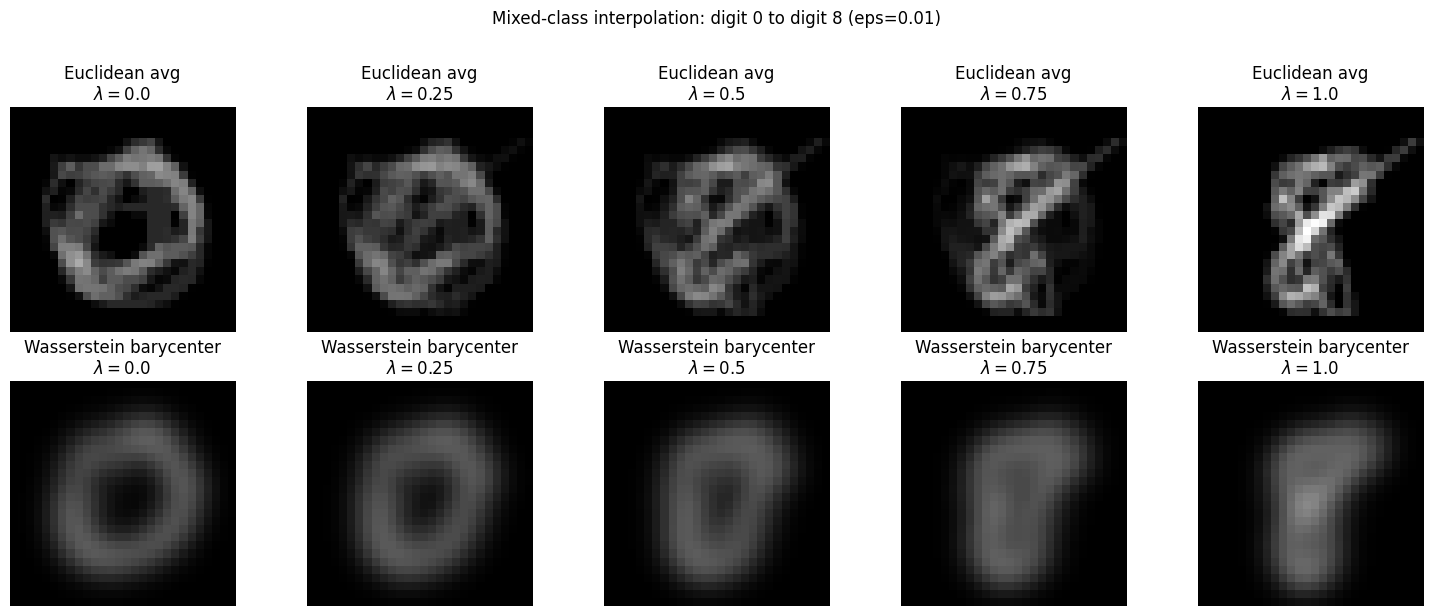

In [30]:
all_imgs = [mixed_euclidean[lam] for lam in LAMBDAS] + [mixed_wasserstein[lam] for lam in LAMBDAS]
vmax = max(img.reshape(28, 28).max() for img in all_imgs)

fig, axes = plt.subplots(2, len(LAMBDAS), figsize=(3 * len(LAMBDAS), 6))

for k, lam in enumerate(LAMBDAS):
    axes[0, k].imshow(mixed_euclidean[lam].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    axes[0, k].set_title(f"Euclidean avg\n$\\lambda={lam}$")
    axes[0, k].axis("off")

    axes[1, k].imshow(mixed_wasserstein[lam].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    axes[1, k].set_title(f"Wasserstein barycenter\n$\\lambda={lam}$")
    axes[1, k].axis("off")

plt.suptitle(
    f"Mixed-class interpolation: digit {LABEL_A} to digit {LABEL_B} "
    f"(eps={MIXED_EPS})",
    y=1.02
)
plt.tight_layout()
plt.show()

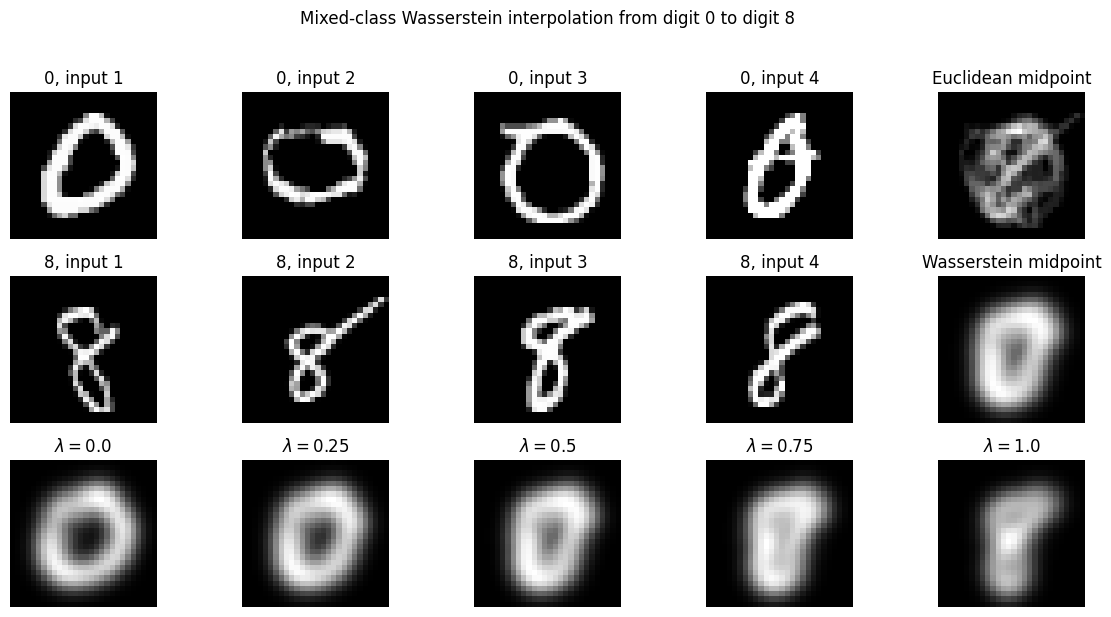

In [31]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(3, 5)

# Row 1: representative inputs from class A
for k in range(4):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(np.asarray(images_A[k]), cmap="gray")
    ax.set_title(f"{LABEL_A}, input {k+1}")
    ax.axis("off")

# Row 2: representative inputs from class B
for k in range(4):
    ax = fig.add_subplot(gs[1, k])
    ax.imshow(np.asarray(images_B[k]), cmap="gray")
    ax.set_title(f"{LABEL_B}, input {k+1}")
    ax.axis("off")

# Put Euclidean midpoint and Wasserstein midpoint on the right
ax_mid_e = fig.add_subplot(gs[0, 4])
ax_mid_e.imshow(mixed_euclidean[0.5].reshape(28, 28), cmap="gray")
ax_mid_e.set_title("Euclidean midpoint")
ax_mid_e.axis("off")

ax_mid_w = fig.add_subplot(gs[1, 4])
ax_mid_w.imshow(mixed_wasserstein[0.5].reshape(28, 28), cmap="gray")
ax_mid_w.set_title("Wasserstein midpoint")
ax_mid_w.axis("off")

# Bottom row: Wasserstein interpolation path
for k, lam in enumerate(LAMBDAS):
    ax = fig.add_subplot(gs[2, k])
    ax.imshow(mixed_wasserstein[lam].reshape(28, 28), cmap="gray")
    ax.set_title(f"$\\lambda={lam}$")
    ax.axis("off")

plt.suptitle(
    f"Mixed-class Wasserstein interpolation from digit {LABEL_A} to digit {LABEL_B}",
    y=1.02
)
plt.tight_layout()
plt.show()

In [32]:
mixed_fig_path = FIG_DIR / f"mixed_class_{LABEL_A}_to_{LABEL_B}_eps_{str(MIXED_EPS).replace('.', 'p')}.png"

all_imgs = [mixed_euclidean[lam] for lam in LAMBDAS] + [mixed_wasserstein[lam] for lam in LAMBDAS]
vmax = max(img.reshape(28, 28).max() for img in all_imgs)

fig, axes = plt.subplots(2, len(LAMBDAS), figsize=(3 * len(LAMBDAS), 6))

for k, lam in enumerate(LAMBDAS):
    axes[0, k].imshow(mixed_euclidean[lam].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    axes[0, k].set_title(f"Euclidean avg\n$\\lambda={lam}$")
    axes[0, k].axis("off")

    axes[1, k].imshow(mixed_wasserstein[lam].reshape(28, 28), cmap="gray", vmin=0, vmax=vmax)
    axes[1, k].set_title(f"Wasserstein barycenter\n$\\lambda={lam}$")
    axes[1, k].axis("off")

plt.suptitle(
    f"Mixed-class interpolation: digit {LABEL_A} to digit {LABEL_B} "
    f"(eps={MIXED_EPS})",
    y=1.02
)
plt.tight_layout()
plt.savefig(mixed_fig_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved:", mixed_fig_path)

Saved: /home/choukrani/ot/outputs/figures/mixed_class_0_to_8_eps_0p01.png


In [33]:
print(f"Mixed-class interpolation summary: {LABEL_A} -> {LABEL_B}")
print("-" * 70)
print(f"{'lambda':>8} | {'runtime (s)':>12} | {'eucl max':>12} | {'bary max':>12}")
print("-" * 70)

for lam in LAMBDAS:
    eucl = mixed_euclidean[lam]
    bary = mixed_wasserstein[lam]
    print(
        f"{lam:8.2f} | {mixed_runtime[lam]:12.4f} | "
        f"{eucl.max():12.4e} | {bary.max():12.4e}"
    )

Mixed-class interpolation summary: 0 -> 8
----------------------------------------------------------------------
  lambda |  runtime (s) |     eucl max |     bary max
----------------------------------------------------------------------
    0.00 |      18.6674 |   8.2708e-03 |   4.5283e-03
    0.25 |      17.9585 |   7.3348e-03 |   4.4350e-03
    0.50 |      18.4597 |   7.8695e-03 |   4.4310e-03
    0.75 |      17.7023 |   9.2360e-03 |   4.7805e-03
    1.00 |      16.9035 |   1.2315e-02 |   6.5500e-03


## Retrieval comparison

In [34]:
# Small retrieval experiment:
# candidates from train, queries from test

CANDIDATES_PER_LABEL = 10   # 10 x 10 = 100 candidates total
QUERIES_PER_LABEL = 1       # 1 x 10 = 10 queries total

cand_images, cand_labels, cand_indices = select_balanced_subset(
    train_ds, per_label=CANDIDATES_PER_LABEL, labels=range(10), seed=0
)

query_images, query_labels, query_indices = select_balanced_subset(
    test_ds, per_label=QUERIES_PER_LABEL, labels=range(10), seed=1
)

print(f"Retrieval experiment: {len(query_images)} queries, {len(cand_images)} candidates.")

Retrieval experiment: 10 queries, 100 candidates.


In [35]:
# Euclidean baseline: flattened grayscale vectors in [0,1]^784
G_eucl = batch_images_to_unit_interval_vectors(cand_images)
Q_eucl = batch_images_to_unit_interval_vectors(query_images)

# Sinkhorn: histograms in Delta_784
G_hist = batch_images_to_histograms(cand_images, eta=ETA)
Q_hist = batch_images_to_histograms(query_images, eta=ETA)

In [36]:
D_eucl = euclidean_query_candidate_distances(Q_eucl, G_eucl)
nn_eucl = retrieval_topk_indices(D_eucl, k=5)
stats_eucl = topk_same_label_stats(nn_eucl, query_labels, cand_labels, k=5)

print("Euclidean retrieval stats:")
print(stats_eucl)

Euclidean retrieval stats:
{'top1_accuracy': 0.6, 'topk_same_label_fraction': 0.5}


In [37]:
RETR_EPS = 0.01
RETR_MAX_ITER = 800
RETR_STOP_THR = 1e-4

D_sink, runtime_sink = sinkhorn_query_candidate_distances(
    Q_hist,
    G_hist,
    C_mnist,
    eps=RETR_EPS,
    numItermax=RETR_MAX_ITER,
    stopThr=RETR_STOP_THR,
    verbose=True,
)

nn_sink = retrieval_topk_indices(D_sink, k=5)
stats_sink = topk_same_label_stats(nn_sink, query_labels, cand_labels, k=5)

Query 1/10
Query 2/10
Query 3/10
Query 4/10
Query 5/10
Query 6/10
Query 7/10
Query 8/10
Query 9/10
Query 10/10


In [38]:
print("Retrieval summary")
print("-" * 50)
print(f"{'Method':<15} {'Top-1 acc':>12} {'Top-5 same-label frac':>24}")
print("-" * 50)
print(f"{'Euclidean':<15} {stats_eucl['top1_accuracy']:12.4f} {stats_eucl['topk_same_label_fraction']:24.4f}")
print(f"{'Sinkhorn':<15} {stats_sink['top1_accuracy']:12.4f} {stats_sink['topk_same_label_fraction']:24.4f}")
print("-" * 50)

Retrieval summary
--------------------------------------------------
Method             Top-1 acc    Top-5 same-label frac
--------------------------------------------------
Euclidean             0.6000                   0.5000
Sinkhorn              0.7000                   0.5800
--------------------------------------------------


In [39]:
for i in range(len(query_labels)):
    eucl_labels = cand_labels[nn_eucl[i]]
    sink_labels = cand_labels[nn_sink[i]]

    print(
        f"Query {i} | true label={query_labels[i]} | "
        f"Eucl top-5={eucl_labels.tolist()} | "
        f"Sinkhorn top-5={sink_labels.tolist()}"
    )

Query 0 | true label=0 | Eucl top-5=[0, 0, 5, 5, 7] | Sinkhorn top-5=[0, 3, 0, 0, 0]
Query 1 | true label=1 | Eucl top-5=[1, 1, 1, 8, 1] | Sinkhorn top-5=[1, 1, 6, 8, 8]
Query 2 | true label=2 | Eucl top-5=[2, 2, 2, 1, 1] | Sinkhorn top-5=[2, 2, 2, 2, 2]
Query 3 | true label=3 | Eucl top-5=[6, 3, 8, 1, 8] | Sinkhorn top-5=[8, 3, 6, 8, 8]
Query 4 | true label=4 | Eucl top-5=[1, 7, 4, 8, 1] | Sinkhorn top-5=[6, 7, 9, 6, 4]
Query 5 | true label=5 | Eucl top-5=[5, 5, 3, 7, 5] | Sinkhorn top-5=[5, 5, 5, 5, 9]
Query 6 | true label=6 | Eucl top-5=[6, 2, 6, 2, 4] | Sinkhorn top-5=[6, 6, 6, 3, 2]
Query 7 | true label=7 | Eucl top-5=[7, 7, 7, 7, 7] | Sinkhorn top-5=[7, 7, 7, 7, 7]
Query 8 | true label=8 | Eucl top-5=[9, 4, 7, 9, 8] | Sinkhorn top-5=[8, 7, 8, 7, 8]
Query 9 | true label=9 | Eucl top-5=[7, 9, 9, 9, 4] | Sinkhorn top-5=[4, 7, 9, 7, 8]


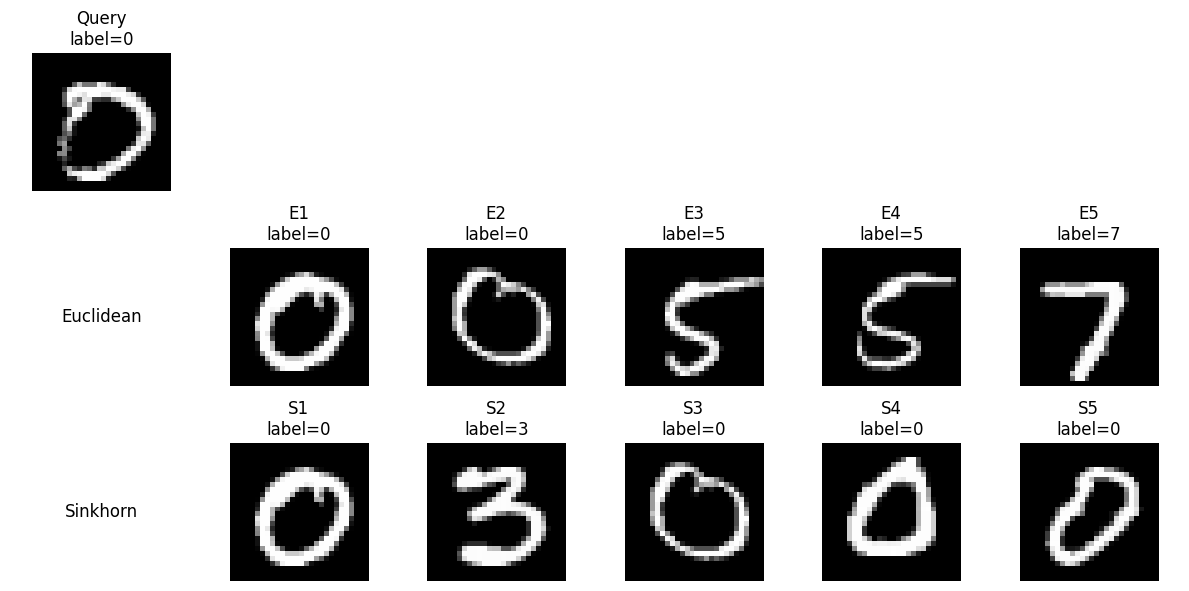

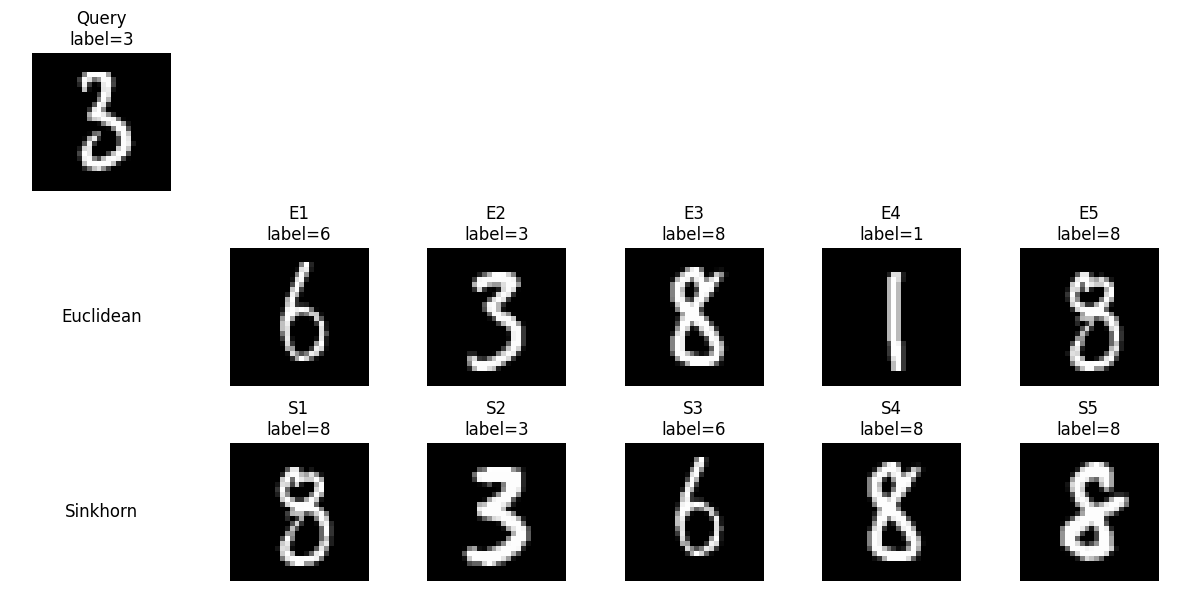

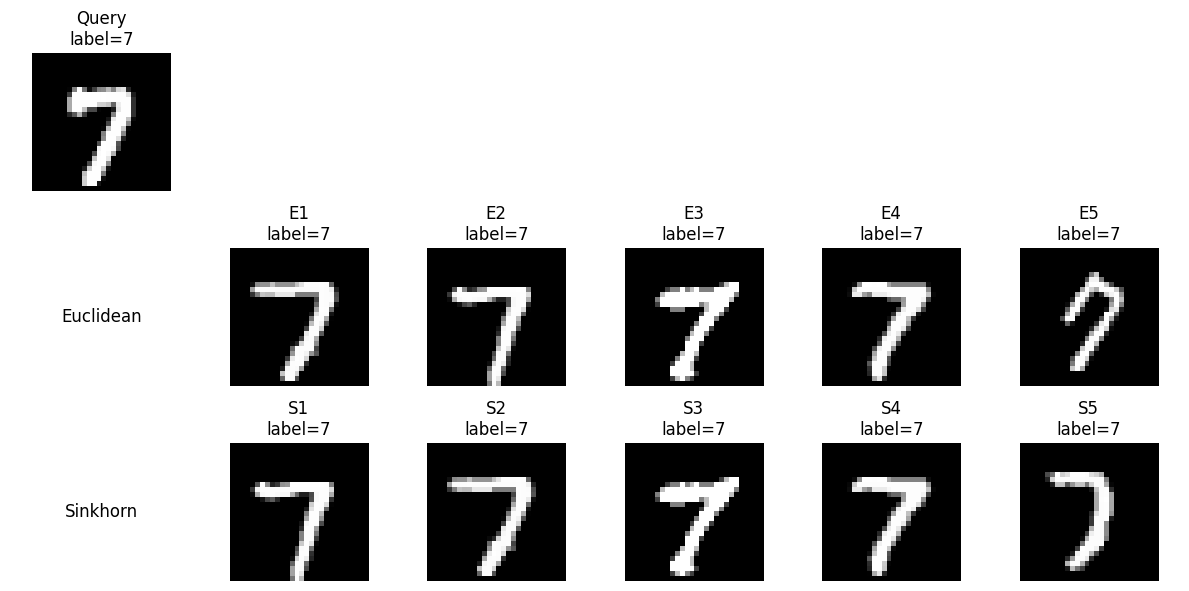

In [40]:
# Show a few representative queries
QUERY_IDS_TO_SHOW = [0, 3, 7]

for qid in QUERY_IDS_TO_SHOW:
    show_retrieval_panel(
        query_idx=qid,
        query_images=query_images,
        query_labels=query_labels,
        query_indices=query_indices,
        cand_images=cand_images,
        cand_labels=cand_labels,
        cand_indices=cand_indices,
        nn_eucl=nn_eucl,
        nn_sink=nn_sink,
        k=5,
    )

In [41]:
retrieval_fig_path = FIG_DIR / "retrieval_comparison_query0.png"

qid = 0
k = 5

fig, axes = plt.subplots(3, k + 1, figsize=(2 * (k + 1), 6))

axes[0, 0].imshow(np.asarray(query_images[qid]), cmap="gray")
axes[0, 0].set_title(f"Query\nlabel={query_labels[qid]}")
axes[0, 0].axis("off")

axes[1, 0].text(0.5, 0.5, "Euclidean", ha="center", va="center", fontsize=12)
axes[1, 0].axis("off")

axes[2, 0].text(0.5, 0.5, "Sinkhorn", ha="center", va="center", fontsize=12)
axes[2, 0].axis("off")

for r in range(1, k + 1):
    axes[0, r].axis("off")

for r, cand_id in enumerate(nn_eucl[qid, :k], start=1):
    axes[1, r].imshow(np.asarray(cand_images[cand_id]), cmap="gray")
    axes[1, r].set_title(f"E{r}\nlabel={cand_labels[cand_id]}")
    axes[1, r].axis("off")

for r, cand_id in enumerate(nn_sink[qid, :k], start=1):
    axes[2, r].imshow(np.asarray(cand_images[cand_id]), cmap="gray")
    axes[2, r].set_title(f"S{r}\nlabel={cand_labels[cand_id]}")
    axes[2, r].axis("off")

plt.tight_layout()
plt.savefig(retrieval_fig_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved:", retrieval_fig_path)

Saved: /home/choukrani/ot/outputs/figures/retrieval_comparison_query0.png
